In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("../..").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    ARM_LINK,
    CARTESIAN_CONTROL_CACHE_PATH,
    CC_ABLATION_RESULTS_DIR,
    CC_AMP_REG,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_BAND_CHANNELS,
    CC_CONSTRAIN_ELBOW,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SH_DRIFT_THRESH,
    CC_SH_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    MAX_DELTA,
    aggregate_seed_metrics,
    run_cartesian_control,
)
from cartesian_control_ablation_band_scale import (
    NOTEBOOK_GITHUB_URL,
    make_band_scale_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
ABLATION_SEEDS = list(range(10))
EL_BAND_SCALES = [0.1, 0.2, 0.3, 0.4, 0.6]  # S± fixed at 1.0

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
if CC_OPTIMAL_PARAMS_PATH.exists():
    with open(CC_OPTIMAL_PARAMS_PATH) as fh:
        optimal_params = json.load(fh)
    print(f"Loaded optimal params from {CC_OPTIMAL_PARAMS_PATH.name}")
else:
    optimal_params = {}
    print("Optimal params not found — using defaults from constants.py")

CC_ABLATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

base_params = dict(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T,
    n_r=CC_N_R,
    n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN,
    target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK,
    r_effort=CC_R_EFFORT,
    q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH,
    sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS,
    a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS,
    a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    constrain_elbow=CC_CONSTRAIN_ELBOW,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS,
    open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

Loaded optimal params from cc_optimal_params.json


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
ablation_results = {}
for el_scale in EL_BAND_SCALES:
    band_scale = [1.0, 1.0, el_scale, el_scale]
    per_seed: list = []
    for seed in ABLATION_SEEDS:
        slug = f"{el_scale:.1f}".replace(".", "p")
        sim_params: dict[str, Any] = {
            **base_params,
            **optimal_params,
            "band_scale": band_scale,
            "demo_seed": seed,
            "results_path": CC_ABLATION_RESULTS_DIR / f"band_scale_{slug}_{seed}.pkl",
        }
        results, _, _ = run_cartesian_control(**sim_params)
        per_seed.append(results)
    ablation_results[el_scale] = aggregate_seed_metrics(
        per_seed, T=CC_T, dist_thresh=CC_DIST_THRESH
    )

print("\nAblation summary (mean ± SD across seeds):")
for scale, agg in ablation_results.items():
    fd = agg["final_dist"]
    fr = agg["frac_in_sector"]
    print(
        f"  E±scale={scale:.1f}: final_dist={fd.mean():.2f}±{fd.std():.2f}  frac={fr.mean():.3f}±{fr.std():.3f}"
    )

Loading cached results from band_scale_0p1_0.pkl
Loading cached results from band_scale_0p1_1.pkl
Loading cached results from band_scale_0p1_2.pkl
Loading cached results from band_scale_0p1_3.pkl
Loading cached results from band_scale_0p1_4.pkl
Loading cached results from band_scale_0p1_5.pkl
Loading cached results from band_scale_0p1_6.pkl
Loading cached results from band_scale_0p1_7.pkl
Loading cached results from band_scale_0p1_8.pkl
Loading cached results from band_scale_0p1_9.pkl
Loading cached results from band_scale_0p2_0.pkl
Loading cached results from band_scale_0p2_1.pkl
Loading cached results from band_scale_0p2_2.pkl
Loading cached results from band_scale_0p2_3.pkl
Loading cached results from band_scale_0p2_4.pkl
Loading cached results from band_scale_0p2_5.pkl
Loading cached results from band_scale_0p2_6.pkl
Loading cached results from band_scale_0p2_7.pkl
Loading cached results from band_scale_0p2_8.pkl
Loading cached results from band_scale_0p2_9.pkl
Loading cached resul

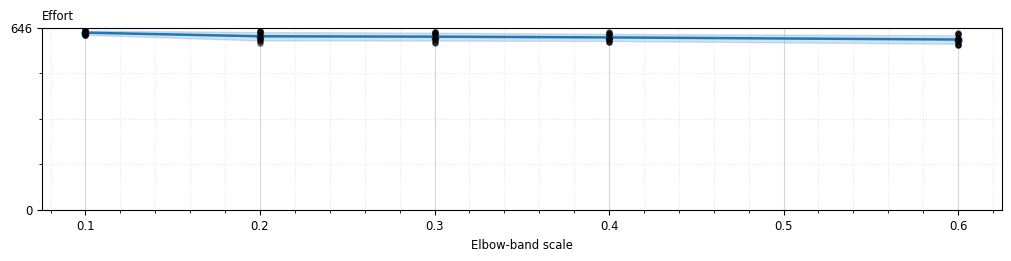

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_band_scale_figure(ablation_results, figsize=(10.0, 2.5))
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.50
FIG_HEIGHT_FRAC = 0.14

configure_pgf()
fig = make_band_scale_figure(
    ablation_results,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_ablation_band_scale.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_ablation_band_scale.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
n_seeds = len(ABLATION_SEEDS)
n_trials = CC_N_R * CC_N_THETA
scale_vals_str = ", ".join(str(s) for s in EL_BAND_SCALES)

caption = (
    r"Ablation over the E\textpm\ band-scale gain $\in \{"
    + scale_vals_str
    + r"\}$ (S\textpm\ fixed at 1.0) on "
    f"{n_trials} targets across $N={n_seeds}$ Brain seeds "
    f"($T={CC_T}$ steps). "
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_ablation_band_scale.tex",
    caption,
    NOTEBOOK_GITHUB_URL,
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_ablation_band_scale.tex
Ablation over the E\textpm\ band-scale gain $\in \{0.1, 0.2, 0.3, 0.4, 0.6\}$ (S\textpm\ fixed at 1.0) on 24 targets across $N=10$ Brain seeds ($T=1000$ steps). 
